# Out-of-the-Box DeepLabCut Evaluation for XROMM

## Study Goal
Build a reproducible benchmark for out-of-the-box pre-trained DeepLabCut models within the XROMM workflow (X-Ray Of Moving Morphology).

## FAIR Alignment
- **Findable**: each trial receives deterministic split metadata and a global split manifest.
- **Accessible**: all artifacts are written as CSV/JSON in the trial folders.
- **Interoperable**: coordinate schema is preserved from the original `LabeledBodyPartsCoordinates.csv`.
- **Reusable**: split logic is versioned, seed-controlled, and idempotent.

## Input and Output Layout

### Expected Input Per Trial
`{Bird}_{Trial}/CompleteSet/Cam1`, `Cam2`, and `LabeledBodyPartsCoordinates.csv`

### Generated Output Per Trial
- `train/Cam1`, `train/Cam2`, `train/LabeledBodyPartsCoordinates.csv`
- `test/Cam1`, `test/Cam2`, `test/LabeledBodyPartsCoordinates.csv`
- `split_metadata.json` (test/train indices + provenance)

### Global Output
- `Data/split_manifest.csv` summarizing every trial split run

In [1]:
from pathlib import Path
import json
import pandas as pd

from dataset_splitter import split_all_trials

In [2]:
# Reproducible split settings
DATA_ROOT = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data")
TEST_FRAME_COUNT = 300
SEED = 42
OVERWRITE_EXISTING_SPLITS = True

DATA_ROOT

WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCutExperiments/Data')

In [3]:
manifest_df = split_all_trials(
    data_root=DATA_ROOT,
    test_frame_count=TEST_FRAME_COUNT,
    seed=SEED,
    overwrite=OVERWRITE_EXISTING_SPLITS,
)

manifest_df

,trial_name,trial_path,available_frames,requested_test_frames,selected_test_frames,selected_train_frames,skipped,reason
0,DB_T15,C:\Users\Salle-Cineradio\Documents\MachineLear...,2980,300,300,2680,False,
1,DB_T16,C:\Users\Salle-Cineradio\Documents\MachineLear...,762,300,300,462,False,
2,DB_T17,C:\Users\Salle-Cineradio\Documents\MachineLear...,1560,300,300,1260,False,
3,Tulio_T10,C:\Users\Salle-Cineradio\Documents\MachineLear...,2849,300,300,2549,False,
4,Tulio_T5,C:\Users\Salle-Cineradio\Documents\MachineLear...,1229,300,300,929,False,


In [4]:
# Quick quality checks
summary = {
    "n_trials": int(len(manifest_df)),
    "n_skipped": int(manifest_df["skipped"].sum()) if "skipped" in manifest_df.columns else 0,
    "n_processed": int((~manifest_df["skipped"]).sum()) if "skipped" in manifest_df.columns else int(len(manifest_df)),
}
summary

{'n_trials': 5, 'n_skipped': 0, 'n_processed': 5}

In [5]:
# Inspect one trial metadata file to verify deterministic indices are stored
trial_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])
sample_trial = trial_dirs[0] if trial_dirs else None
if sample_trial is None:
    raise RuntimeError("No trial folders found under DATA_ROOT")

metadata_path = sample_trial / "split_metadata.json"
metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
metadata

{'version': 1,
 'created_unix': 1783617775,
 'trial_name': 'DB_T15',
 'trial_path': 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCutExperiments\\Data\\DB_T15',
 'seed': 42,
 'test_frame_count_requested': 300,
 'available_frames_used': 2980,
 'cam1_image_count': 2980,
 'cam2_image_count': 2980,
 'csv_row_count': 2980,
 'test_indices': [2,
  8,
  13,
  26,
  29,
  47,
  60,
  79,
  86,
  102,
  108,
  122,
  128,
  130,
  131,
  177,
  187,
  192,
  207,
  221,
  229,
  237,
  240,
  241,
  248,
  260,
  262,
  271,
  276,
  283,
  284,
  290,
  292,
  308,
  322,
  326,
  350,
  356,
  372,
  379,
  382,
  383,
  386,
  396,
  397,
  401,
  403,
  413,
  418,
  419,
  435,
  447,
  449,
  456,
  458,
  469,
  495,
  511,
  515,
  525,
  541,
  566,
  571,
  574,
  585,
  626,
  636,
  647,
  653,
  655,
  661,
  666,
  669,
  674,
  676,
  681,
  700,
  731,
  751,
  779,
  784,
  787,
  814,
  823,
  858,
  864,
  867,
  870,
  875,
  877,
  

## Build Three Training Sets Per Trial (Dataset Creation Only)

From each trial's `train/` split, create model-input subsets:

- `random_train`
- `displacement_train` (zone size 150)
- `dino_train`

This stage mirrors `train_update_model` setup through dataset creation and **stops before model training** (`dlcs.create_and_train`).

In [6]:
from training_sets.dataset_builder import build_three_training_sets_for_all_trials

TRAINING_NFRAMES = (100, 50)
TRAINING_EPOCHS = 125
TRAINING_SEED = 42
DISPLACEMENT_ZONE_SIZE = 150

TRAINING_NFRAMES, TRAINING_EPOCHS, TRAINING_SEED, DISPLACEMENT_ZONE_SIZE

((100, 50), 125, 42, 150)

In [7]:
training_manifest_df = build_three_training_sets_for_all_trials(
    data_root=DATA_ROOT,
    nframes_values=TRAINING_NFRAMES,
    epochs=TRAINING_EPOCHS,
    frame_selection_seed=TRAINING_SEED,
    zone_size=DISPLACEMENT_ZONE_SIZE,
)

training_manifest_df

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-09\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-09\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-09\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-09\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architectu

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-09\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-09\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-09\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-09\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\D

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


...

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Tulio_T5\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-09\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Tulio_T5\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-09\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Tulio_T5\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-09\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Tulio_T5\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-09\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\P

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Tulio_T5\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-09\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Tulio_T5\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-09\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Tulio_T5\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-09\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\Tulio_T5\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-09\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Proce

,trial_folder,bird,trial_num,method,nframes,epochs,output_root,config_path,selection_count,status,message
0,DB_T15,DavidBowie,15,random,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
1,DB_T15,DavidBowie,15,displacement,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
2,DB_T15,DavidBowie,15,dino,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
3,DB_T15,DavidBowie,15,random,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created
4,DB_T15,DavidBowie,15,displacement,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created
5,DB_T15,DavidBowie,15,dino,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created
6,DB_T16,DavidBowie,16,random,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
7,DB_T16,DavidBowie,16,displacement,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
8,DB_T16,DavidBowie,16,dino,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
9,DB_T16,DavidBowie,16,random,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created


## Provenance Notes

- Splits are deterministic from `SEED=42`.
- If Cam1/Cam2/CSV lengths differ, the split uses the aligned minimum count to maintain row-image correspondence.
- This notebook is designed for repeated reruns as new trial folders are added to `Data/`.

## Next Benchmark Steps

1. Train/evaluate out-of-the-box pretrained DeepLabCut models on each split.
2. Compute per-trial and pooled error metrics against held-out `test` labels.
3. Export a model-comparison table and publication figures with confidence intervals.
4. Record software/version metadata for full reproducibility in manuscript supplements.

## Embedding Comparison of Split Usage

This reproduces the Cell 67-style embedding scatter view for one trial:

- all images in dark background points
- bright overlays for selected frames from `random_train`, `displacement_train`, `dino_train`
- bright overlay for held-out `test` frames

In [8]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import transforms

try:
    import umap
except Exception:
    umap = None


TRIAL_FOR_EMBED_VIS = "DB_T15"  # Example: DB_T15, DB_T16, DB_T17, Tulio_T10, Tulio_T5
NFRAMES_FOR_METHOD_METADATA = 100  # pick 100 or 50
CAMERA_FOR_EMBED_VIS = "Cam1"

DINO_BATCH_SIZE = 32
DINO_MODEL_NAME = "dinov2_vits14"
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "cosine"
RANDOM_SEED = 42


def _image_sort_key(path: Path) -> tuple[int, str]:
    match = re.search(r"(\d+)(?!.*\d)", path.stem)
    idx = int(match.group(1)) if match else -1
    return idx, path.name.lower()


def _list_images_sorted(folder: Path) -> list[Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts], key=_image_sort_key)


def _read_selected_indices(trial_dir: Path, method_name: str, nframes: int) -> list[int]:
    metadata_path = trial_dir / f"{method_name}_train" / f"nframes_{int(nframes)}" / "dataset_build_metadata.json"
    if not metadata_path.exists():
        return []
    data = json.loads(metadata_path.read_text(encoding="utf-8"))
    return [int(x) for x in data.get("selected_indices", [])]


def _load_split_test_filenames(trial_dir: Path, camera: str = "Cam1") -> set[str]:
    test_dir = trial_dir / "test" / camera
    return {p.name for p in _list_images_sorted(test_dir)}


def _compute_dino_embeddings(image_paths: list[Path], batch_size: int = 32, model_name: str = "dinov2_vits14") -> np.ndarray:
    if not image_paths:
        raise ValueError("No images found for embedding computation")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval().to(device)

    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )

    all_feats = []
    for start in range(0, len(image_paths), int(batch_size)):
        batch_paths = image_paths[start : start + int(batch_size)]
        batch_tensors = []
        for image_path in batch_paths:
            with Image.open(image_path) as image_file:
                batch_tensors.append(transform(image_file.convert("RGB")))
        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            feats = model(batch)
        all_feats.append(feats.detach().cpu())

    embeddings = torch.cat(all_feats, dim=0)
    embeddings = embeddings / embeddings.norm(dim=1, keepdim=True).clamp_min(1e-12)
    return embeddings.numpy()


DATA_ROOT = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data")
TRIAL_DIR = DATA_ROOT / TRIAL_FOR_EMBED_VIS

if not TRIAL_DIR.exists():
    raise FileNotFoundError(f"Trial folder not found: {TRIAL_DIR}")

COMPLETE_CAM_DIR = TRIAL_DIR / "CompleteSet" / CAMERA_FOR_EMBED_VIS
TRAIN_CAM_DIR = TRIAL_DIR / "train" / CAMERA_FOR_EMBED_VIS

complete_images = _list_images_sorted(COMPLETE_CAM_DIR)
train_images = _list_images_sorted(TRAIN_CAM_DIR)

if not complete_images:
    raise RuntimeError(f"No complete-set images found in: {COMPLETE_CAM_DIR}")
if not train_images:
    raise RuntimeError(f"No train-set images found in: {TRAIN_CAM_DIR}")

# Compute DINO embeddings for all complete-set images (background cloud)
embeddings = _compute_dino_embeddings(
    complete_images,
    batch_size=DINO_BATCH_SIZE,
    model_name=DINO_MODEL_NAME,
)

if umap is not None:
    reducer = umap.UMAP(
        n_neighbors=UMAP_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric=UMAP_METRIC,
        random_state=RANDOM_SEED,
    )
    embedding_2d = reducer.fit_transform(embeddings)
else:
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    embedding_2d = pca.fit_transform(embeddings)

# Build index sets for overlays by mapping selected train image names into complete-set positions.
complete_name_to_idx = {p.name: i for i, p in enumerate(complete_images)}
train_name_list = [p.name for p in train_images]

method_to_indices = {}
for method in ("random", "displacement", "dino"):
    train_local_indices = _read_selected_indices(TRIAL_DIR, method, NFRAMES_FOR_METHOD_METADATA)
    selected_names = [train_name_list[i] for i in train_local_indices if 0 <= i < len(train_name_list)]
    method_to_indices[method] = np.asarray([complete_name_to_idx[name] for name in selected_names if name in complete_name_to_idx], dtype=int)

test_names = _load_split_test_filenames(TRIAL_DIR, CAMERA_FOR_EMBED_VIS)
test_indices = np.asarray([complete_name_to_idx[name] for name in test_names if name in complete_name_to_idx], dtype=int)

print(
    {
        "trial": TRIAL_FOR_EMBED_VIS,
        "camera": CAMERA_FOR_EMBED_VIS,
        "n_all_images": len(complete_images),
        "n_random": int(method_to_indices["random"].size),
        "n_displacement": int(method_to_indices["displacement"].size),
        "n_dino": int(method_to_indices["dino"].size),
        "n_test": int(test_indices.size),
        "reducer": "UMAP" if umap is not None else "PCA (fallback)",
    }
)

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'trial': 'DB_T15', 'camera': 'Cam1', 'n_all_images': 2980, 'n_random': 100, 'n_displacement': 100, 'n_dino': 100, 'n_test': 300, 'reducer': 'UMAP'}


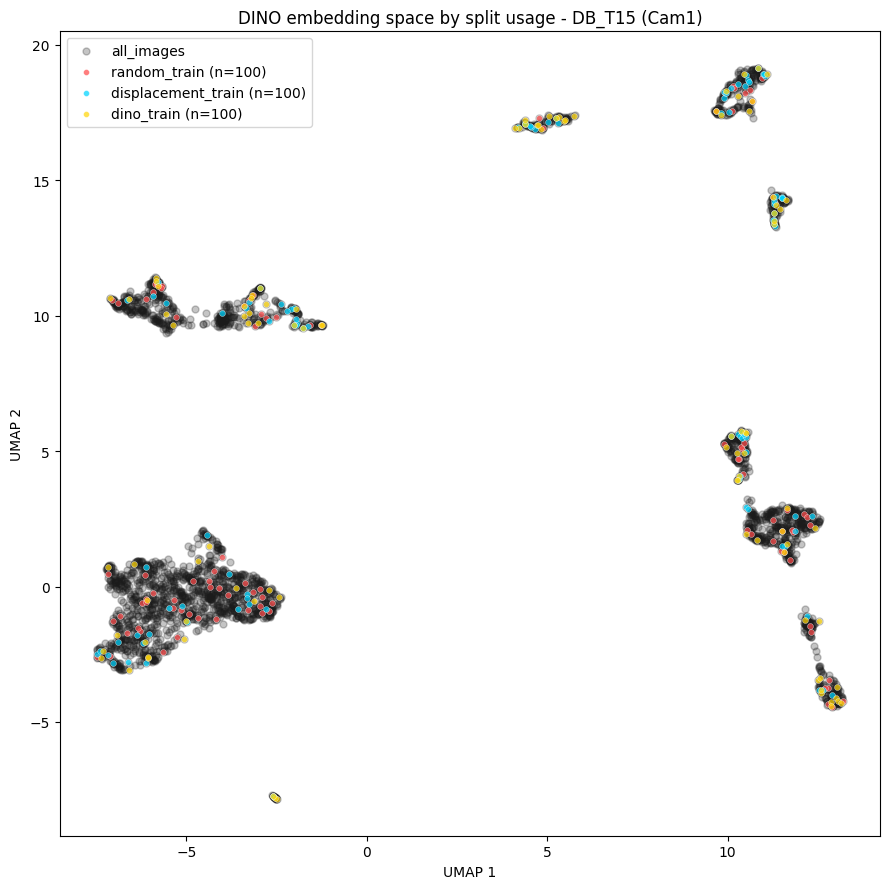

In [13]:
# Cell-67-style scatter overlay: dark background cloud + bright split selections
plt.figure(figsize=(9, 9))

# All images (background)
plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=25,
    alpha=0.25,
    c="#1b1b1b",
    label="all_images",
)

overlay_specs = [
    ("random", "#ff4d4d"),
    ("displacement", "#00d4ff"),
    ("dino", "#ffd60a"),
]

for method_name, color in overlay_specs:
    idx = method_to_indices.get(method_name, np.asarray([], dtype=int))
    if idx.size == 0:
        continue
    plt.scatter(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        s=18,
        alpha=0.72,
        c=color,
        edgecolors="white",
        linewidths=0.35,
        label=f"{method_name}_train (n={idx.size})",
    )

# if test_indices.size > 0:
#     plt.scatter(
#         embedding_2d[test_indices, 0],
#         embedding_2d[test_indices, 1],
#         s=25,
#         alpha=0.95,
#         c="#39ff14",
#         marker="^",
#         edgecolors="black",
#         linewidths=0.45,
#         label=f"test_split (n={test_indices.size})",
#     )

plt.legend(loc="best", frameon=True)
plt.title(f"DINO embedding space by split usage - {TRIAL_FOR_EMBED_VIS} ({CAMERA_FOR_EMBED_VIS})")
plt.xlabel("UMAP 1" if umap is not None else "PC 1")
plt.ylabel("UMAP 2" if umap is not None else "PC 2")
plt.tight_layout()
plt.show()

### All-Trials Split Embedding Grid

Run this to generate the same split-overlay visualization for every trial in `Data/`.

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap

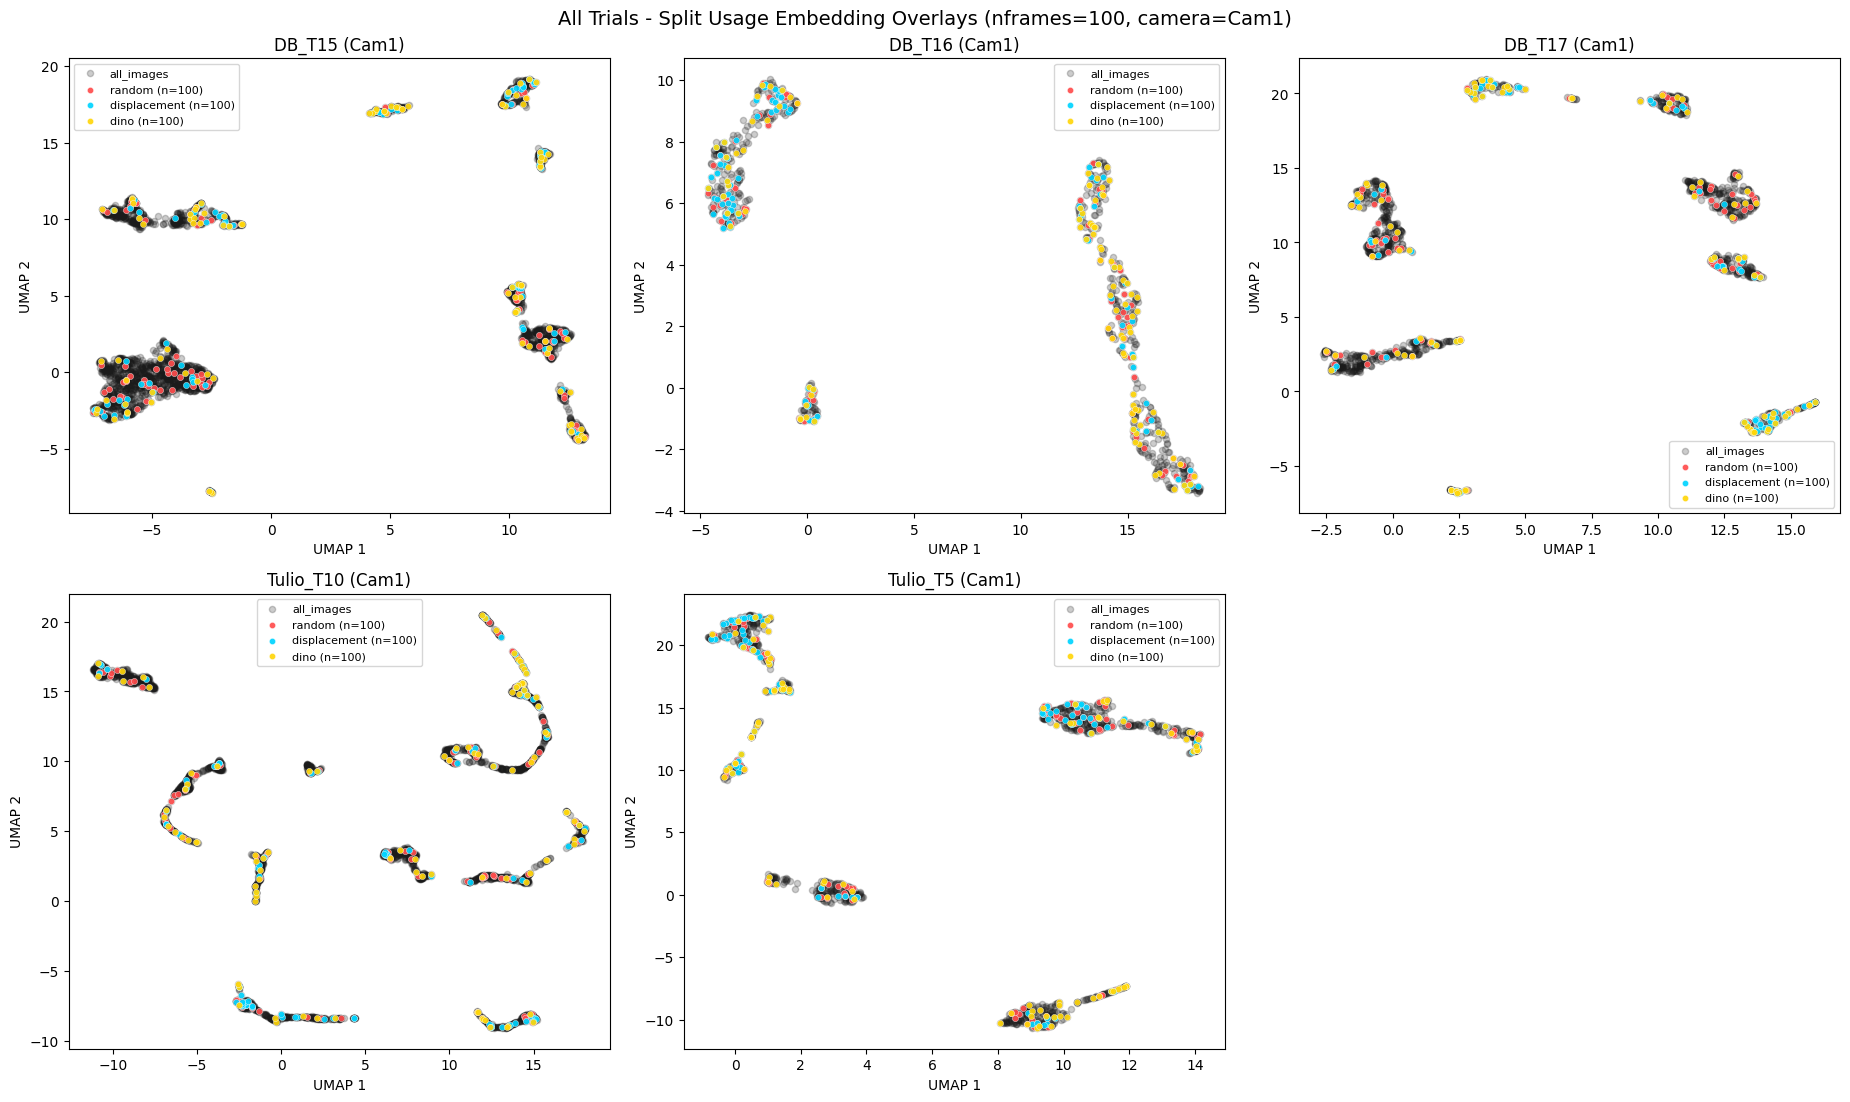

In [14]:
import math


def _build_dino_model_once(model_name: str = "dinov2_vits14"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval().to(device)
    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )
    return model, transform, device


def _compute_embeddings_with_model(image_paths, model, transform, device, batch_size: int = 32):
    feats = []
    for start in range(0, len(image_paths), int(batch_size)):
        batch_paths = image_paths[start : start + int(batch_size)]
        batch_tensors = []
        for image_path in batch_paths:
            with Image.open(image_path) as image_file:
                batch_tensors.append(transform(image_file.convert("RGB")))
        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            out = model(batch)
        feats.append(out.detach().cpu())

    emb = torch.cat(feats, dim=0)
    emb = emb / emb.norm(dim=1, keepdim=True).clamp_min(1e-12)
    return emb.numpy()


def plot_all_trials_split_embeddings(
    data_root: Path,
    nframes: int = 100,
    camera: str = "Cam1",
    batch_size: int = 32,
    ncols: int = 3,
):
    trial_dirs = sorted([p for p in data_root.iterdir() if p.is_dir() and (p / "CompleteSet" / camera).exists()])
    if len(trial_dirs) == 0:
        raise RuntimeError(f"No trials found under {data_root} for camera {camera}")

    model, transform, device = _build_dino_model_once(model_name=DINO_MODEL_NAME)

    nrows = math.ceil(len(trial_dirs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 5.6 * nrows), squeeze=False)

    for idx_trial, trial_dir in enumerate(trial_dirs):
        ax = axes[idx_trial // ncols][idx_trial % ncols]

        complete_images = _list_images_sorted(trial_dir / "CompleteSet" / camera)
        train_images = _list_images_sorted(trial_dir / "train" / camera)

        if len(complete_images) == 0 or len(train_images) == 0:
            ax.set_title(f"{trial_dir.name} ({camera}) - missing images")
            ax.axis("off")
            continue

        embeddings = _compute_embeddings_with_model(
            complete_images,
            model=model,
            transform=transform,
            device=device,
            batch_size=batch_size,
        )

        if umap is not None:
            reducer = umap.UMAP(
                n_neighbors=UMAP_NEIGHBORS,
                min_dist=UMAP_MIN_DIST,
                metric=UMAP_METRIC,
                random_state=RANDOM_SEED,
            )
            embedding_2d = reducer.fit_transform(embeddings)
            xlab, ylab = "UMAP 1", "UMAP 2"
        else:
            from sklearn.decomposition import PCA

            pca = PCA(n_components=2, random_state=RANDOM_SEED)
            embedding_2d = pca.fit_transform(embeddings)
            xlab, ylab = "PC 1", "PC 2"

        complete_name_to_idx = {p.name: i for i, p in enumerate(complete_images)}
        train_name_list = [p.name for p in train_images]

        method_to_indices = {}
        for method in ("random", "displacement", "dino"):
            train_local_indices = _read_selected_indices(trial_dir, method, int(nframes))
            selected_names = [train_name_list[i] for i in train_local_indices if 0 <= i < len(train_name_list)]
            method_to_indices[method] = np.asarray(
                [complete_name_to_idx[name] for name in selected_names if name in complete_name_to_idx],
                dtype=int,
            )

        test_names = _load_split_test_filenames(trial_dir, camera)
        test_indices = np.asarray([complete_name_to_idx[name] for name in test_names if name in complete_name_to_idx], dtype=int)

        ax.scatter(
            embedding_2d[:, 0],
            embedding_2d[:, 1],
            s=20,
            alpha=0.22,
            c="#1b1b1b",
            label="all_images",
        )

        overlay_specs = [
            ("random", "#ff4d4d"),
            ("displacement", "#00d4ff"),
            ("dino", "#ffd60a"),
        ]
        for method_name, color in overlay_specs:
            local_idx = method_to_indices.get(method_name, np.asarray([], dtype=int))
            if local_idx.size == 0:
                continue
            ax.scatter(
                embedding_2d[local_idx, 0],
                embedding_2d[local_idx, 1],
                s=20,
                alpha=0.92,
                c=color,
                edgecolors="white",
                linewidths=0.30,
                label=f"{method_name} (n={local_idx.size})",
            )

        # if test_indices.size > 0:
        #     ax.scatter(
        #         embedding_2d[test_indices, 0],
        #         embedding_2d[test_indices, 1],
        #         s=34,
        #         alpha=0.95,
        #         c="#39ff14",
        #         marker="^",
        #         edgecolors="black",
        #         linewidths=0.40,
        #         label=f"test (n={test_indices.size})",
        #     )

        ax.set_title(f"{trial_dir.name} ({camera})")
        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)
        ax.legend(loc="best", fontsize=8, frameon=True)

    for k in range(len(trial_dirs), nrows * ncols):
        axes[k // ncols][k % ncols].axis("off")

    fig.suptitle(f"All Trials - Split Usage Embedding Overlays (nframes={nframes}, camera={camera})", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_all_trials_split_embeddings(
    data_root=DATA_ROOT,
    nframes=NFRAMES_FOR_METHOD_METADATA,
    camera=CAMERA_FOR_EMBED_VIS,
    batch_size=DINO_BATCH_SIZE,
    ncols=3,
)

### Full Suite Training (Single GPU, Trial-Agnostic Timing)

Run the next cell to train the entire generated suite (`random`, `displacement`, `dino` × `nframes` 100/50) on a single GPU.

This writes a run-level manifest with per-job timing (`elapsed_seconds`), which we summarize in the following analysis cell.

In [15]:
import json
import shlex
import subprocess
import sys
import time
from pathlib import Path

import pandas as pd


# Resolve paths robustly whether notebook is opened at repo root or DeepLabCutExperiments/
def _resolve_training_paths() -> tuple[Path, Path]:
    cwd = Path.cwd().resolve()

    direct_script = cwd / "training_sets" / "train_all_models.py"
    direct_manifest = cwd / "Data" / "training_set_build_manifest.csv"
    if direct_script.exists() and direct_manifest.exists():
        return direct_script, direct_manifest

    nested_script = cwd / "DeepLabCutExperiments" / "training_sets" / "train_all_models.py"
    nested_manifest = cwd / "DeepLabCutExperiments" / "Data" / "training_set_build_manifest.csv"
    if nested_script.exists() and nested_manifest.exists():
        return nested_script, nested_manifest

    raise FileNotFoundError(
        "Could not resolve training script/manifest. Expected either "
        "training_sets/train_all_models.py + Data/training_set_build_manifest.csv "
        "or DeepLabCutExperiments/training_sets/train_all_models.py + "
        "DeepLabCutExperiments/Data/training_set_build_manifest.csv from current working directory."
    )


TRAIN_SCRIPT, TRAINING_SET_BUILD_MANIFEST = _resolve_training_paths()
TRAINING_DATA_DIR = TRAINING_SET_BUILD_MANIFEST.parent

# Single-GPU full-suite defaults
EPOCHS = 125
METHODS = ["random", "displacement", "dino"]
NFRAMES = [100, 50]
MAX_WORKERS = 1  # single GPU

# Keep conservative defaults for single GPU stability; tune upward later if VRAM allows.
TRAIN_NETWORK_KWARGS = {
    "batch_size": 12,
    # "dataloader_workers": 0,
    # "dataloader_pin_memory": False,
}

cmd = [
    sys.executable,
    "-u",  # unbuffered output so notebook shows progress lines live
    str(TRAIN_SCRIPT),
    "--manifest",
    str(TRAINING_SET_BUILD_MANIFEST),
    "--epochs",
    str(EPOCHS),
    "--methods",
    *METHODS,
    "--nframes",
    *[str(v) for v in NFRAMES],
    "--max-workers",
    str(MAX_WORKERS),
    "--train-network-kwargs-json",
    json.dumps(TRAIN_NETWORK_KWARGS),
]

print("Launching training command:")
print(" ".join(shlex.quote(x) for x in cmd))
print("\nExpected progress format:")
print("- [train-job i/N] Bird_Ttrial | nframes=... | method=...")
print("- [epoch-progress] ... [#####-----] epoch/total")
print("- [suite-progress] completed=.../N ok=... error=...")

wall_t0 = time.perf_counter()
proc = subprocess.run(cmd, check=False)
wall_elapsed = time.perf_counter() - wall_t0

print(f"\nTraining process return code: {proc.returncode}")
print(f"Wall-clock elapsed: {wall_elapsed/3600:.2f} hours")

run_manifests = sorted(
    TRAINING_DATA_DIR.glob("training_run_manifest_*.csv"),
    key=lambda p: p.stat().st_mtime,
)
LATEST_TRAINING_RUN_MANIFEST = run_manifests[-1] if run_manifests else None
print("Latest run manifest:", LATEST_TRAINING_RUN_MANIFEST)

Launching training command:
'c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\python.exe' -u 'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\training_sets\train_all_models.py' --manifest 'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest.csv' --epochs 125 --methods random displacement dino --nframes 100 50 --max-workers 1 --train-network-kwargs-json '{"batch_size": 12}'

Expected progress format:
- [train-job i/N] Bird_Ttrial | nframes=... | method=...
- [epoch-progress] ... [#####-----] epoch/total
- [suite-progress] completed=.../N ok=... error=...

Training process return code: 0
Wall-clock elapsed: 5.41 hours
Latest run manifest: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_run_manifest_20260710_010211.csv


### Trial-Agnostic Summary Across 6 Model Dimensions

This summarizes timing and status pooled across trials by `(nframes, method)`:
- `nframes`: 100 or 50
- `method`: `random`, `displacement`, `dino`

Together these define the 6 model dimensions you asked to compare.

In [16]:
from pathlib import Path

import pandas as pd

if "LATEST_TRAINING_RUN_MANIFEST" not in globals() or LATEST_TRAINING_RUN_MANIFEST is None:
    data_dir = Path("Data") if Path("Data").exists() else Path("DeepLabCutExperiments") / "Data"
    manifests = sorted(data_dir.glob("training_run_manifest_*.csv"), key=lambda p: p.stat().st_mtime)
    if not manifests:
        raise FileNotFoundError("No training_run_manifest_*.csv found. Run the training cell first.")
    LATEST_TRAINING_RUN_MANIFEST = manifests[-1]

print("Using manifest:", LATEST_TRAINING_RUN_MANIFEST)
run_df = pd.read_csv(LATEST_TRAINING_RUN_MANIFEST)

required = {"bird", "trial_num", "method", "nframes", "status", "elapsed_seconds"}
missing = required - set(run_df.columns)
if missing:
    raise ValueError(f"Manifest missing required columns: {sorted(missing)}")

run_df = run_df.copy()
run_df["elapsed_seconds"] = pd.to_numeric(run_df["elapsed_seconds"], errors="coerce")
run_df["elapsed_minutes"] = run_df["elapsed_seconds"] / 60.0
run_df["elapsed_hours"] = run_df["elapsed_seconds"] / 3600.0
run_df["method"] = run_df["method"].astype(str).str.lower().str.strip()
run_df["trial_key"] = run_df["bird"].astype(str) + "_T" + run_df["trial_num"].astype(int).astype(str)
run_df["is_ok"] = run_df["status"].astype(str).str.lower().eq("ok")

trial_agnostic_summary = (
    run_df.groupby(["nframes", "method"], dropna=False)
    .agg(
        n_jobs=("status", "size"),
        n_ok=("is_ok", "sum"),
        success_rate=("is_ok", "mean"),
        mean_minutes=("elapsed_minutes", "mean"),
        median_minutes=("elapsed_minutes", "median"),
        std_minutes=("elapsed_minutes", "std"),
        min_minutes=("elapsed_minutes", "min"),
        max_minutes=("elapsed_minutes", "max"),
    )
    .reset_index()
    .sort_values(["nframes", "method"])
)
trial_agnostic_summary["success_rate"] = (100.0 * trial_agnostic_summary["success_rate"]).round(1)

print("\nTrial-agnostic (6-dimension) timing summary:")
display(trial_agnostic_summary)

# Keep a trial-level table available for later variance analyses.
trial_level_summary = (
    run_df.groupby(["trial_key", "nframes", "method"], dropna=False)
    .agg(
        n_jobs=("status", "size"),
        n_ok=("is_ok", "sum"),
        mean_minutes=("elapsed_minutes", "mean"),
        median_minutes=("elapsed_minutes", "median"),
    )
    .reset_index()
    .sort_values(["trial_key", "nframes", "method"])
)

summary_out = Path(LATEST_TRAINING_RUN_MANIFEST).with_name(
    Path(LATEST_TRAINING_RUN_MANIFEST).stem + "_trial_agnostic_summary.csv"
)
trial_agnostic_summary.to_csv(summary_out, index=False)
print("Saved trial-agnostic summary:", summary_out)

Using manifest: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_run_manifest_20260710_010211.csv

Trial-agnostic (6-dimension) timing summary:


,nframes,method,n_jobs,n_ok,success_rate,mean_minutes,median_minutes,std_minutes,min_minutes,max_minutes
0,50,dino,5,4,80.0,7.253887,9.040227,4.054601,0.000977,9.107535
1,50,displacement,5,4,80.0,7.262236,9.062426,4.059221,0.000981,9.103719
2,50,random,5,4,80.0,7.269838,9.082564,4.063474,0.000985,9.112572
3,100,dino,5,4,80.0,14.406201,17.994283,8.052828,0.001071,18.063637
4,100,displacement,5,4,80.0,14.314477,17.823597,8.002838,0.000988,18.063654
5,100,random,5,4,80.0,14.428690,18.041264,8.065734,0.001072,18.130754


Saved trial-agnostic summary: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_run_manifest_20260710_010211_trial_agnostic_summary.csv


In [33]:
from Predictions import (
    evaluate_within_across_all_birds,
    evaluate_within_across_for_bird,
)

In [35]:
from pathlib import Path

import pandas as pd


# -----------------------------
# User settings
# -----------------------------
RUN_ALL_BIRDS = True
BIRD_TO_EVAL = "DavidBowie"  # Used when RUN_ALL_BIRDS = False
THRESHOLD_PX = 5.0
FPS_FOR_STACK_TO_AVI = 500
BATCHSIZE_FOR_INFERENCE = 16
DELETE_INTERMEDIATE_PREDICTIONS = False
FORCE_REBUILD_AVI = True  # Critical: avoids stale AVI length causing frame overrun


# -----------------------------
# Path resolution
# -----------------------------
def _resolve_paths() -> tuple[Path, Path]:
    cwd = Path.cwd().resolve()

    direct_data = cwd / "Data"
    direct_manifest = direct_data / "training_set_build_manifest.csv"
    if direct_manifest.exists():
        return direct_data, direct_manifest

    nested_data = cwd / "DeepLabCutExperiments" / "Data"
    nested_manifest = nested_data / "training_set_build_manifest.csv"
    if nested_manifest.exists():
        return nested_data, nested_manifest

    raise FileNotFoundError(
        "Could not resolve Data/training_set_build_manifest.csv from cwd. "
        "Open notebook from DeepLabCutExperiments/ or repo root."
    )


DATA_ROOT, BUILD_MANIFEST_PATH = _resolve_paths()

print("Data root:", DATA_ROOT)
print("Build manifest:", BUILD_MANIFEST_PATH)


if RUN_ALL_BIRDS:
    out = evaluate_within_across_all_birds(
        data_root=DATA_ROOT,
        build_manifest_path=BUILD_MANIFEST_PATH,
        birds=None,
        threshold_px=THRESHOLD_PX,
        fps=FPS_FOR_STACK_TO_AVI,
        batchsize=BATCHSIZE_FOR_INFERENCE,
        delete_intermediate_predictions=DELETE_INTERMEDIATE_PREDICTIONS,
        force_rebuild_avi=FORCE_REBUILD_AVI,
    )
    scores_df = out["combined_scores_df"]

    print("\nAll-birds evaluation complete.")
    print("Rows in combined scores:", len(scores_df))
    display(
        scores_df.sort_values(["bird", "eval_trial", "pair_type", "rmse_px", "method", "nframes"])[
            [
                "bird",
                "train_trial",
                "eval_trial",
                "pair_type",
                "method",
                "nframes",
                "rmse_px",
                "percent_points_within_threshold",
                "percent_frames_all_points_within_threshold",
                "mean_n_predictions_within_threshold_per_frame",
                "std_n_predictions_within_threshold_per_frame",
                "n_points_compared",
                "status",
            ]
        ]
    )
else:
    out = evaluate_within_across_for_bird(
        bird=BIRD_TO_EVAL,
        data_root=DATA_ROOT,
        build_manifest_path=BUILD_MANIFEST_PATH,
        threshold_px=THRESHOLD_PX,
        fps=FPS_FOR_STACK_TO_AVI,
        batchsize=BATCHSIZE_FOR_INFERENCE,
        delete_intermediate_predictions=DELETE_INTERMEDIATE_PREDICTIONS,
        force_rebuild_avi=FORCE_REBUILD_AVI,
    )

    scores_df = out["scores_df"]
    full_scores_csv = out["full_scores_csv"]
    full_errors_csv = out["full_errors_csv"]
    per_eval_paths = out["per_eval_paths"]

    print("\nDone.")
    print("Saved full scores:", full_scores_csv)
    if full_errors_csv is not None:
        print("Saved full point-level errors:", full_errors_csv)
    print("Saved per-eval score files:")
    for p in per_eval_paths:
        print("-", p)

    ok_view = scores_df[scores_df["status"] == "ok"].copy()
    if not ok_view.empty:
        display(
            ok_view.sort_values(["eval_trial", "pair_type", "rmse_px", "method", "nframes"])[
                [
                    "bird",
                    "train_trial",
                    "eval_trial",
                    "pair_type",
                    "method",
                    "nframes",
                    "rmse_px",
                    "percent_points_within_threshold",
                    "percent_frames_all_points_within_threshold",
                    "mean_n_predictions_within_threshold_per_frame",
                    "std_n_predictions_within_threshold_per_frame",
                    "n_points_compared",
                ]
            ]
        )
    else:
        display(scores_df)

Data root: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data
Build manifest: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest.csv
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\dino_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-09\dlc-models-pytorch\iteration-0\CanariJul9-trainset95shuffle1\train\snapshot-125.pt
Using scorer: DLC_Resnet50_CanariJul9shuffle1_snapshot_125
Video C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\test\Cam1.avi already analyzed at C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\test\Cam1DLC_Resnet50_CanariJul9shuffle1_snapshot_125_full.pickle!
Video C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\D

KeyboardInterrupt: 